In [6]:
import os, random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torchvision import transforms
from torchsummary import summary
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split

import qiskit
from qiskit.circuit.library import RealAmplitudes, NLocal, ZZFeatureMap
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister, Parameter, ParameterVector
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
import pylatexenc

ImportError: cannot import name 'BaseEstimator' from 'qiskit.primitives' (E:\Anaconda\Lib\site-packages\qiskit\primitives\__init__.py)

In [187]:
max_in_class = 200
train_part = 0.5
noise = 0.1
batch_size = 30

epochs = 30
initial_lr = 0.0005

device = "cpu"

In [165]:
class CSVDataset(Dataset):
    def __init__(self, dataframe):
        self.data = dataframe.reset_index(drop=True)
        self.X = self.data.iloc[:, :-1].values
        self.y = self.data.iloc[:, -1].values

        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [167]:
# Загрузка данных
df = pd.read_csv("email_phishing_data.csv")

# Перемешиваем
df = shuffle(df, random_state=42)

# Разделяем по меткам
df_0 = df[df.iloc[:, -1] == 0].reset_index(drop=True)
df_1 = df[df.iloc[:, -1] == 1].reset_index(drop=True)

# Выбираем по 3000 с каждой меткой для тренировочной выборки
train_0 = df_0.iloc[:6000]
train_1 = df_1.iloc[:6000]

train_df = pd.concat([train_0, train_1])
train_df = shuffle(train_df, random_state=42)

# Остатки (после первых 3000)
remaining_0 = df_0.iloc[3000:]
remaining_1 = df_1.iloc[3000:]

# Для теста: минимум 2000 с меткой 1, остальное — с меткой 0
test_1 = remaining_1.iloc[:6000]
needed_0 = 15000 - len(test_1)
test_0 = remaining_0.iloc[:needed_0]

# Объединяем и перемешиваем
test_df = pd.concat([test_0, test_1])
test_df = shuffle(test_df, random_state=42)

train_dataset = CSVDataset(train_df)
test_dataset = CSVDataset(test_df)

train_dataloader = DataLoader(train_dataset, batch_size= batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True)
print(len(train_dataloader.dataset), len(test_dataloader.dataset))

12000 15000


In [189]:
tens_1 = torch.Tensor([[1]]*batch_size)

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(8, 32)
        self.fc2 = nn.Linear(32, 16)
        self.drop = nn.Dropout(0.05)
        self.fc3 = nn.Linear(16, 2)
        self.drop = nn.Dropout(0.05)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim = 1)
        return x

In [191]:
model = SimpleNN()
#summary(model, (1, 28, 28), batch_size, device = device)
print(model)

SimpleNN(
  (fc1): Linear(in_features=8, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (drop): Dropout(p=0.05, inplace=False)
  (fc3): Linear(in_features=16, out_features=2, bias=True)
)


In [193]:
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
loss_fn = nn.CrossEntropyLoss()

In [195]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    train_loss, correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device).float(), y.to(device)

        # Compute prediction error
        #print(X, data_prep(X))
        pred = model(X)
        loss = loss_fn(pred, y)

        train_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    if batch % 100 == 0:
        loss, current = loss.item(), (batch + 1) * len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    train_loss /= num_batches
    correct /= size

    return correct, train_loss

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device).float(), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return correct, test_loss

In [197]:
history = {
    'train_loss':[],
    'train_accuracy':[],
    'val_loss':[],
    'val_accuracy':[],
    'test_loss':[],
    'test_accuracy':[]
}

for t in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    print(f"Epoch {t+1}\n-------------------------------")
    #if(t % 2 == 0):
    #    initial_lr /= 2
    #    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
    acc, loss = train(train_dataloader, model, loss_fn, optimizer)
    history['train_accuracy'].append(acc)
    history['train_loss'].append(loss)
    acc, loss = test(test_dataloader, model, loss_fn)
    history['val_accuracy'].append(acc)
    history['val_loss'].append(loss)
print("Done!")

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 43.3%, Avg loss: 0.710817 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 50.7%, Avg loss: 0.668593 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 55.2%, Avg loss: 0.650849 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 61.5%, Avg loss: 0.626799 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 70.6%, Avg loss: 0.595939 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 70.1%, Avg loss: 0.594868 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 59.7%, Avg loss: 0.654724 

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 73.1%, Avg loss: 0.573972 

Epoch 9
-------------------------------
Test Error: 
 Accuracy: 76.1%, Avg loss: 0.558202 

Epoch 10
-------------------------------
Test Error: 
 Accuracy: 68.0%, Avg loss: 0.607654 

Epoch 11
-------------------------------
Test Error: 
 Accuracy: 75.9%, Avg los

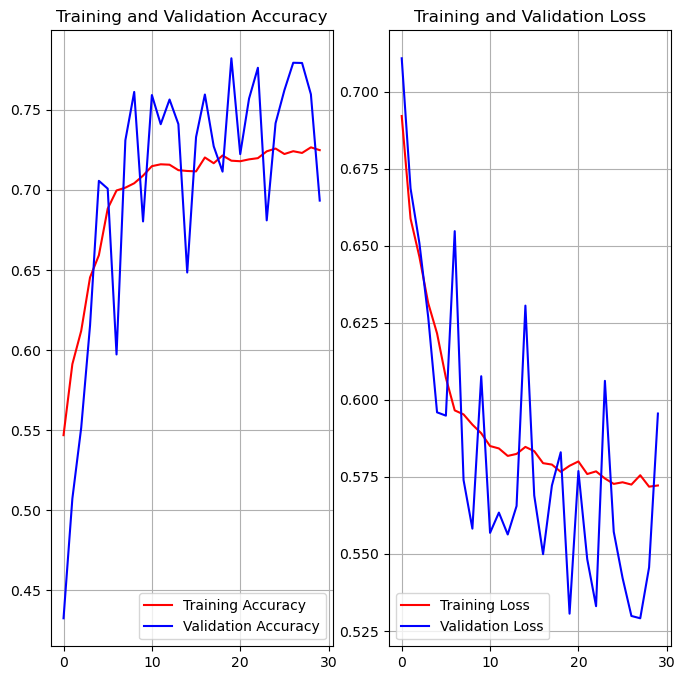

In [199]:
epochs_range = range(epochs)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_accuracy'], label='Training Accuracy', color='red')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='red')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue')
plt.legend(loc='lower left')
plt.title('Training and Validation Loss')
plt.grid()
plt.show()

In [157]:
model.eval()
test_dataloader
predictions = torch.LongTensor().to(device)
cmt = torch.zeros(2, 2, dtype=torch.int32)#Матрица ошибок
with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device).float(), y.to(device)
        preds = model(X.to(device))
        predictions = preds.argmax(dim=1)
        cmt[y, predictions] += 1

In [158]:
pd.set_option('display.max_columns', 2)
pd.DataFrame(cmt.reshape(2, 2))#строка истинное значение, столбец предсказанное

,0,1
0,8162,2889
1,1123,2826
